开始计算网格 (60x60)... 这可能需要一点时间


/tmp/ipykernel_2208/3656240744.py:67: RuntimeWarning: invalid value encountered in divide
  exponent = - (P_over_L * c/H0) * (Hz - H0) / (Om * H0)


绘图完成。


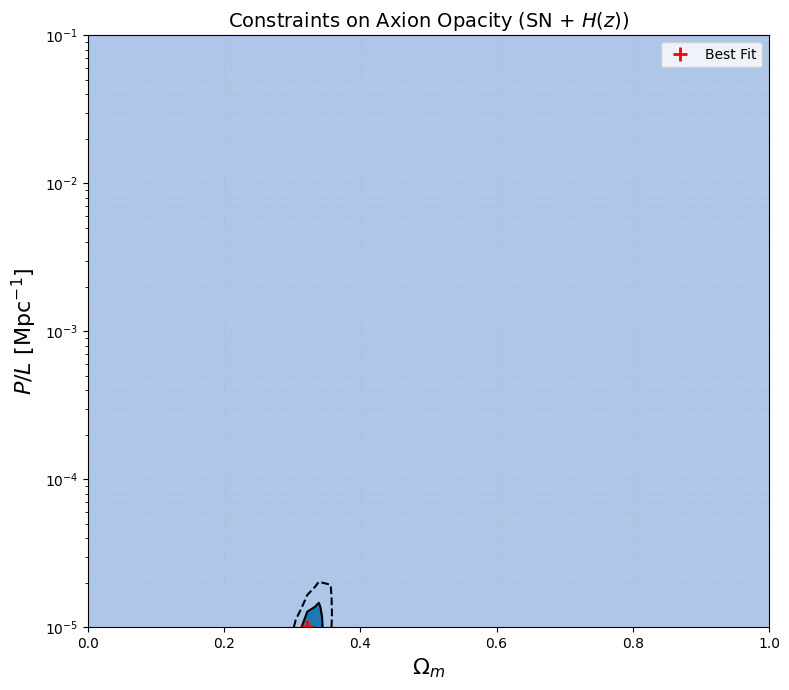

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import pandas as pd

# ==========================================
# 1. 物理常数与配置
# ==========================================
c_light = 299792.458  # 光速 km/s

# 网格精度 (建议 50x50 或更高，越高越平滑但越慢)
GRID_RES = 60

# 参数范围 (参考文中 Figure 3)
om_range = np.linspace(0.0, 1.0, GRID_RES)           # Omega_m
pl_range = np.logspace(-5.0, -1.0, GRID_RES)         # P/L (Mpc^-1)

# H0 扫描范围 (用于边缘化/Profile)
h0_range = np.linspace(60, 80, 20) 

# ==========================================
# 2. 物理模型函数
# ==========================================

def get_Hz_theory(z, Om, H0):
    """理论哈勃参数 H(z)"""
    E = np.sqrt(Om * (1 + z)**3 + (1 - Om))
    return H0 * E

def get_dL_std(z_array, Om, H0):
    """
    标准光度距离 (Mpc), 无轴子
    使用梯形积分加速计算
    """
    if np.isscalar(z_array): z_array = np.array([z_array])
    
    dL_list = []
    for z in z_array:
        if z == 0:
            dL_list.append(0.0)
            continue
        # 积分 1/E(z)
        inv_E = lambda x: 1.0 / np.sqrt(Om * (1 + x)**3 + (1 - Om))
        integ, _ = quad(inv_E, 0, z)
        # dL = (1+z) * (c/H0) * integral
        dL_list.append((1 + z) * (c_light / H0) * integ)
        
    return np.array(dL_list)

def get_survival_prob(z, Om, H0, P_over_L):
    """
    直接对应论文 Eq. (15) 的光子存活概率。
    z        : 红移
    Om       : 物质密度 Omega_m
    H0       : 哈勃常数 (km/s/Mpc)
    P_over_L : P/L (单位 Mpc^-1)
    """
    c = 299792.458  # 光速 km/s
    A = 2.0 / 3.0   # 初始系数
    
    # 1. 计算 H(z)
    Hz = H0 * np.sqrt(Om * (1 + z)**3 + (1 - Om))
    
    # 2. 直接写出 Eq. 15 的指数部分
    # 公式: - (P/L) * (c/H0) * [(H(z) - H0) / (Om * H0)]
    # (c/H0) 是为了抵消 H0 的时间单位，将其转化为距离单位
    exponent = - (P_over_L * c/H0) * (Hz - H0) / (Om * H0)
    
    # 3. 返回概率
    return A + (1 - A) * np.exp(exponent)

def get_mu_theory(z, Om, H0, PL):
    """计算含轴子效应的理论距离模数"""
    # 1. 标准距离
    dL_std = get_dL_std(z, Om, H0)
    
    # 2. 存活概率
    prob = get_survival_prob(z, Om, H0, PL)
    prob = np.maximum(prob, 1e-9) # 防止数值错误
    
    # 3. 修正距离: dL_obs = dL_true / sqrt(P)
    dL_mod = dL_std / np.sqrt(prob)
    
    # 4. 距离模数 (处理 dL=0 的情况)
    with np.errstate(divide='ignore'):
        mu = 5 * np.log10(dL_mod) + 25
    return mu

# ==========================================
# 3. 数据加载 (在此处替换你的数据)
# ==========================================

def load_real_data():
    """
    在这里填入你的真实数据。
    返回格式必须是 numpy array。
    """
    
    # 假设真实宇宙参数
    Om_true = 0.27
    H0_true = 68
    
    
    sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
    z_sn = sn_df['zHD'].values
    m_obs = sn_df['m_b_corr'].values
    err_sn = sn_df['m_b_corr_err_DIAG'].values

    M_fiducial = -19.247 
    mu_sn = m_obs - M_fiducial


    
    # 2. 模拟 H(z) 数据 (类似 CC data)
    z_hz, H_dv, H_dv_err = np.loadtxt('data/cc.txt', unpack=True)

    return z_sn, mu_sn, err_sn, z_hz, H_dv, H_dv_err

# ==========================================
# 4. 核心计算 (Grid Search + Profiling)
# ==========================================

# 加载数据
z_sn, mu_sn, err_sn, z_hz, val_hz, err_hz = load_real_data()

print(f"开始计算网格 ({GRID_RES}x{GRID_RES})... 这可能需要一点时间")

# 初始化卡方网格
chi2_grid = np.zeros((len(pl_range), len(om_range)))

# 开始循环
for i, pl in enumerate(pl_range):
    for j, om in enumerate(om_range):
        
        # Profile Likelihood:
        # 对于固定的 (Om, PL)，我们扫描 H0 找到最小的 Chi2
        # 这相当于 "marginalized over H0"
        
        min_chi2_at_pixel = 1e9
        
        # 预计算标准距离的形状 (仅与 Om 有关的部分积分)
        
        for h0 in h0_range:
            # --- 1. SN Chi2 ---
            mu_model = get_mu_theory(z_sn, om, h0, pl)
            # 处理可能的 nan/inf
            if np.any(np.isinf(mu_model)) or np.any(np.isnan(mu_model)):
                chi2_sn = 1e9
            else:
                chi2_sn = np.sum(((mu_sn - mu_model) / err_sn)**2)
            
            # --- 2. Hz Chi2 ---
            hz_model = get_Hz_theory(z_hz, om, h0)
            chi2_hz = np.sum(((val_hz - hz_model) / err_hz)**2)
            
            chi2_total = chi2_sn + chi2_hz
            
            if chi2_total < min_chi2_at_pixel:
                min_chi2_at_pixel = chi2_total
        
        chi2_grid[i, j] = min_chi2_at_pixel

# ==========================================
# 5. 绘图 (Figure 3)
# ==========================================

# 计算 Delta Chi2
global_min_chi2 = np.min(chi2_grid) #全局最小值
dchi2 = chi2_grid - global_min_chi2 #chi2差值

# 准备坐标网格
X, Y = np.meshgrid(om_range, pl_range)

plt.figure(figsize=(8, 7))

# 定义置信区间阈值 (2个自由度)
# 68.3% (1sigma) -> 2.30
# 95.4% (2sigma) -> 6.17
# 99.7% (3sigma) -> 11.8
levels = [2.30, 6.17]

# 1. 绘制填色区域 (Confidence Regions)
# 使用 blues 模仿论文配色
contour_fill = plt.contourf(X, Y, dchi2, levels=[0, 2.30, 6.17], 
                            colors=['#1f77b4', '#aec7e8'], 
                            extend='max')

# 2. 绘制轮廓线
contour_lines = plt.contour(X, Y, dchi2, levels=levels, 
                            colors=['k', 'k'], 
                            linewidths=1.5, linestyles=['-', '--'])

# 3. 装饰图片
plt.clabel(contour_lines, inline=True, fontsize=10, fmt={2.30:'68%', 6.17:'95%'})
plt.yscale('log')
plt.xlabel(r'$\Omega_m$', fontsize=16)
plt.ylabel(r'$P/L \ [\mathrm{Mpc}^{-1}]$', fontsize=16)
plt.title(r'Constraints on Axion Opacity (SN + $H(z)$)', fontsize=14)

# 标记最佳拟合点
min_idx = np.unravel_index(np.argmin(chi2_grid), chi2_grid.shape)
best_pl = pl_range[min_idx[0]]
best_om = om_range[min_idx[1]]
plt.plot(best_om, best_pl, 'r+', markersize=10, markeredgewidth=2, label='Best Fit')

plt.legend(loc='upper right')
plt.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()

print("绘图完成。")
plt.show()